# Project 3

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import pandas as pd
import seaborn as sns
from scipy.stats import norm

In [2]:
class Ward:
    def __init__(self, name, arrival_func, u, std, beds=None):
        self.name = name
        self.arrival_func = arrival_func 
        self.u = u
        self.std = std
        self.beds = beds

    def arrival_rate(self, t):
        return self.arrival_func(t)

    def length_of_stay(self):
        return np.random.lognormal(self.u, self.std)

std = np.sqrt(np.log(2))

arrival_a = lambda t: -(1/3650) * t**2 + (1/10) * t
arrival_b = lambda t: (1/5) * arrival_a(t)
arrival_c = lambda t: 6.0 
mu_a = np.log(4 * np.sqrt(2))
mu_b = np.log(6 * np.sqrt(2))
mu_c = np.log(5 * np.sqrt(2))


## Primary task

In [3]:
def get_all_bed_distributions(total_beds):
    return [
        (a, b, total_beds - a - b)
        for a in range(1, total_beds - 1)
        for b in range(1, total_beds - a)
    ]


def simulate_system(*wards, n_days):
    occupancy = [[] for _ in wards]
    stats = {
        "relocated": [0] * len(wards),
        "full": [0] * len(wards),
        "arrivals": [0] * len(wards),
        "history": [[] for _ in wards]
    }

    for day in range(n_days):
        # Fjern patienter der er færdige
        for occ in occupancy:
            occ[:] = [x for x in occ if x > day]

        arrivals = [
            np.random.poisson(w.arrival_rate(day))
            for w in wards
        ]

        for i, (ward, amount) in enumerate(zip(wards, arrivals)):
            stats["arrivals"][i] += amount

            for _ in range(amount):
                if len(occupancy[i]) >= ward.beds:
                    stats["full"][i] += 1

                if len(occupancy[i]) < ward.beds:
                    occupancy[i].append(day + ward.length_of_stay())

                elif i == 1 and len(occupancy[0]) < wards[0].beds:
                    occupancy[0].append(day + ward.length_of_stay())

                else:
                    stats["relocated"][i] += 1

        for i, occ in enumerate(occupancy):
            stats["history"][i].append(len(occ))

    return {
        "relocations": {
            "A": stats["relocated"][0],
            "B": stats["relocated"][1],
            "C": stats["relocated"][2],
            "Total": sum(stats["relocated"])
        },
        "prob_full_on_arrival": {
            k: stats["full"][i] / stats["arrivals"][i] if stats["arrivals"][i] else 0
            for i, k in enumerate("ABC")
        },
        "mean_utilization": {
            k: np.mean(stats["history"][i]) / wards[i].beds
            for i, k in enumerate("ABC")
        },
        "history": stats["history"]
    }


def find_optimal_distribution(distributions, *wards, replications=3):
    best = None
    lowest = float("inf")

    print(f"Testing {len(distributions)} bed distributions...")

    for beds in distributions:
        for ward, beds_amount in zip(wards, beds):
            ward.beds = beds_amount

        total = 0

        for _ in range(replications):
            np.random.seed(42)
            total += simulate_system(*wards, n_days=365)["relocations"]["Total"]

        avg = total / replications

        if avg < lowest:
            lowest = avg
            best = beds

    return best, lowest

In [4]:
np.random.seed(42)

n = 365
total_beds = 75

wards = [
    Ward("Ward A", arrival_func=arrival_a, u=mu_a, std=std, beds=0),
    Ward("Ward B", arrival_func=arrival_b, u=mu_b, std=std, beds=0),
    Ward("Ward C", arrival_func=arrival_c, u=mu_c, std=std, beds=0)
]

dist = get_all_bed_distributions(total_beds)

optimal_beds, min_relocated = find_optimal_distribution(
    dist, *wards, replications=1
)

print("\n--- OPTIMAL CONFIGURATION FOUND ---")
print("\n".join(
    f"Ward {chr(65+i)} Beds: {beds}"
    for i, beds in enumerate(optimal_beds)
))
print(f"Minimum Average Relocated Patients: {min_relocated:.2f}")

for ward, beds in zip(wards, optimal_beds):
    ward.beds = beds

print("\nFinal Results for Optimal Distribution:")
print(simulate_system(*wards, n_days=n))

Testing 2701 bed distributions...

--- OPTIMAL CONFIGURATION FOUND ---
Ward A Beds: 41
Ward B Beds: 2
Ward C Beds: 32
Minimum Average Relocated Patients: 1937.00

Final Results for Optimal Distribution:
{'relocations': {'A': 848, 'B': 285, 'C': 1067, 'Total': 2200}, 'prob_full_on_arrival': {'A': 0.3704674530362604, 'B': 0.8533653846153846, 'C': 0.4776186213070725}, 'mean_utilization': {'A': 0.8646174406949548, 'B': 0.910958904109589, 'C': 0.982277397260274}, 'history': [[0, 0, 0, 0, 1, 2, 3, 3, 4, 5, 5, 6, 6, 6, 5, 6, 9, 9, 10, 11, 11, 9, 8, 9, 13, 15, 17, 17, 16, 16, 14, 15, 15, 17, 18, 22, 25, 28, 30, 29, 28, 28, 39, 38, 41, 41, 40, 37, 33, 34, 35, 32, 36, 33, 30, 35, 39, 41, 39, 40, 41, 41, 40, 41, 41, 36, 35, 36, 35, 41, 41, 40, 38, 39, 40, 41, 41, 40, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 39, 39, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 37, 41, 41, 41, 41, 40, 39, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 38, 41, 40, 41, 4

In [5]:
final = simulate_system(*wards, n_days=n)
history = final["history"]

df_history = pd.DataFrame({
    "A": history[0],
    "B": history[1],
    "C": history[2]
})


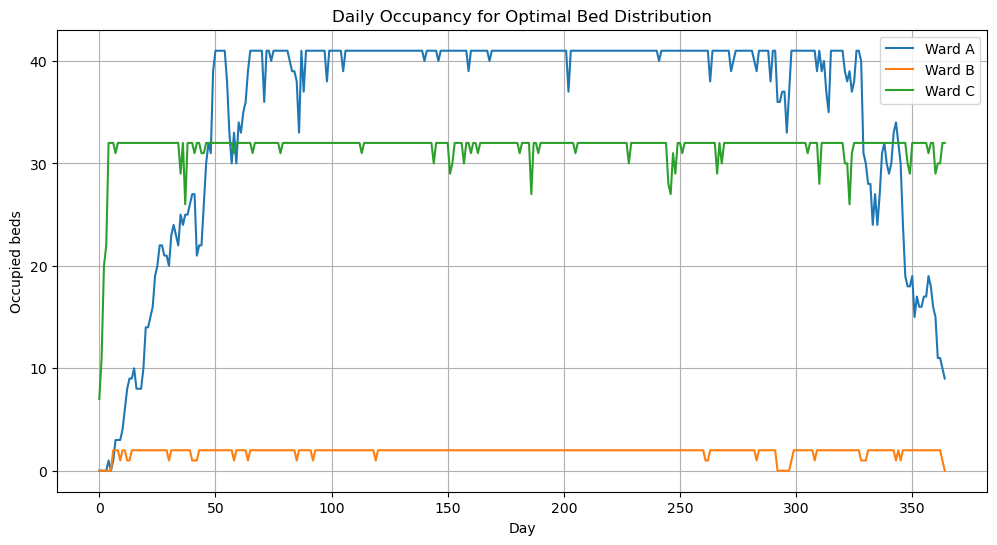

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df_history["A"], label="Ward A")
plt.plot(df_history["B"], label="Ward B")
plt.plot(df_history["C"], label="Ward C")
plt.xlabel("Day")
plt.ylabel("Occupied beds")
plt.title("Daily Occupancy for Optimal Bed Distribution")
plt.legend()
plt.grid(True)
plt.show()


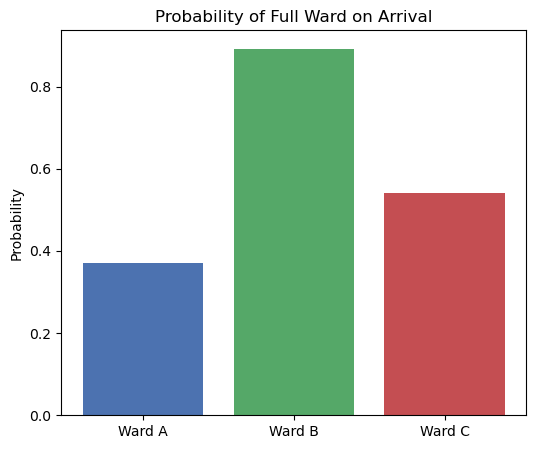

In [7]:
pfull = final["prob_full_on_arrival"]

plt.figure(figsize=(6,5))
plt.bar(["Ward A", "Ward B", "Ward C"],
        [pfull["A"], pfull["B"], pfull["C"]],
        color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Probability")
plt.title("Probability of Full Ward on Arrival")
plt.show()


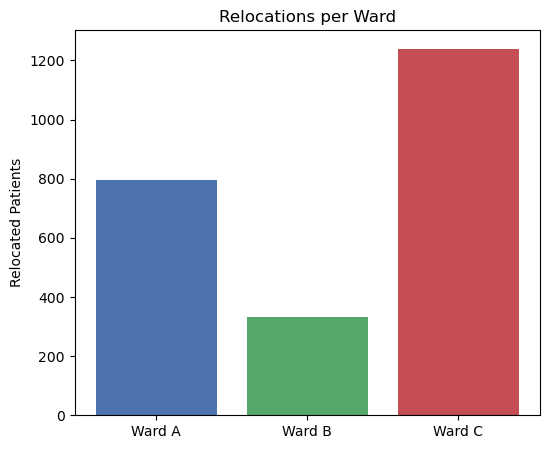

In [8]:
rel = final["relocations"]

plt.figure(figsize=(6,5))
plt.bar(["Ward A", "Ward B", "Ward C"],
        [rel["A"], rel["B"], rel["C"]],
        color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Relocated Patients")
plt.title("Relocations per Ward")
plt.show()


## Primary performance measures

In [9]:
def run_replications(wards, n_days, R):
    results = []

    for r in range(R):
        # vigtigt: ny seed eller ingen seed her, så replications varierer
        res = simulate_system(*wards, n_days=n_days)
        results.append(res)

    return results


In [10]:
random_seed = 42
np.random.seed(random_seed)
for ward, beds in zip(wards, optimal_beds):
    ward.beds = beds

R = 500
results = run_replications(wards, n_days=n, R=R)

In [11]:
pfull = {k: [] for k in "ABC"}
rel = {k: [] for k in ["A", "B", "C", "Total"]}
util = {k: [] for k in "ABC"}

for res in results:
    for k, v in res["prob_full_on_arrival"].items():
        pfull[k].append(v)

    for k, v in res["relocations"].items():
        rel[k].append(v)

    for k, v in res["mean_utilization"].items():
        util[k].append(v)

In [14]:
def ci(x):
    x = np.array(x)
    m = x.mean()
    h = norm.ppf(.975) * x.std(ddof=1) / np.sqrt(len(x))
    return m, m-h, m+h

def show(title, data):
    print(f"\n--- {title} ---")
    for name, values in data.items():
        m, l, u = ci(values)
        print(f"{name}: {m:.3f} (95% CI: [{l:.3f}, {u:.3f}])")

show("Probability full on arrival", {
    "Ward A": pfull["A"],
    "Ward B": pfull["B"],
    "Ward C": pfull["C"]
})

show("Relocations", {
    "Ward A": rel["A"],
    "Ward B": rel["B"],
    "Ward C": rel["C"],
    "Total": rel["Total"]
})

show("Mean utilization", {
    "Ward A": util["A"],
    "Ward B": util["B"],
    "Ward C": util["C"]
})


--- Probability full on arrival ---
Ward A: 0.368 (95% CI: [0.366, 0.369])
Ward B: 0.877 (95% CI: [0.875, 0.878])
Ward C: 0.487 (95% CI: [0.486, 0.489])

--- Relocations ---
Ward A: 816.918 (95% CI: [812.552, 821.284])
Ward B: 302.754 (95% CI: [300.859, 304.649])
Ward C: 1067.460 (95% CI: [1062.478, 1072.442])
Total: 2187.132 (95% CI: [2180.170, 2194.094])

--- Mean utilization ---
Ward A: 0.863 (95% CI: [0.862, 0.864])
Ward B: 0.911 (95% CI: [0.909, 0.912])
Ward C: 0.984 (95% CI: [0.984, 0.984])


## Sensitivity analysis

In [18]:
class Ward_exp:
    def __init__(self, name, arrival_func, u, std, beds=None):
        self.name = name
        self.arrival_func = arrival_func 
        self.u = u
        self.std = std
        self.beds = beds

    def arrival_rate(self, t):
        return self.arrival_func(t)

    def length_of_stay(self):
        return np.random.exponential(self.u)


In [19]:
wards_exp = [
    Ward_exp("Ward A", arrival_func=arrival_a, u=mu_a, std=std, beds=0),
    Ward_exp("Ward B", arrival_func=arrival_b, u=mu_b, std=std, beds=0),
    Ward_exp("Ward C", arrival_func=arrival_c, u=mu_c, std=std, beds=0)
]

In [20]:
np.random.seed(42)

n = 365
total_beds = 75

dist = get_all_bed_distributions(total_beds)

optimal_beds, min_relocated = find_optimal_distribution(
    dist, *wards_exp, replications=1
)

print("\n--- OPTIMAL CONFIGURATION FOUND ---")
print("\n".join(
    f"Ward {chr(65+i)} Beds: {beds}"
    for i, beds in enumerate(optimal_beds)
))
print(f"Minimum Average Relocated Patients: {min_relocated:.2f}")

for ward_exp, beds in zip(wards_exp, optimal_beds):
    ward_exp.beds = beds

print("\nFinal Results for Optimal Distribution:")
print(simulate_system(*wards_exp, n_days=n))

Testing 2701 bed distributions...

--- OPTIMAL CONFIGURATION FOUND ---
Ward A Beds: 34
Ward B Beds: 6
Ward C Beds: 35
Minimum Average Relocated Patients: 0.00

Final Results for Optimal Distribution:
{'relocations': {'A': 0, 'B': 0, 'C': 0, 'Total': 0}, 'prob_full_on_arrival': {'A': 0.0, 'B': 0.11521739130434783, 'C': 0.0}, 'mean_utilization': {'A': 0.42457695406929896, 'B': 0.4940639269406393, 'C': 0.43694716242661447}, 'history': [[0, 0, 0, 0, 1, 1, 1, 0, 2, 1, 2, 2, 1, 3, 2, 1, 1, 0, 1, 2, 2, 3, 4, 5, 7, 7, 3, 4, 6, 5, 5, 8, 6, 9, 9, 5, 4, 9, 7, 5, 2, 5, 7, 4, 7, 6, 11, 7, 13, 11, 11, 10, 9, 11, 7, 7, 4, 2, 5, 6, 11, 15, 15, 12, 13, 8, 8, 8, 11, 5, 10, 8, 6, 8, 12, 9, 12, 15, 12, 8, 13, 14, 15, 22, 11, 13, 15, 17, 15, 19, 17, 11, 10, 9, 11, 17, 15, 18, 14, 16, 13, 17, 13, 19, 19, 15, 17, 20, 20, 18, 23, 18, 19, 20, 16, 12, 15, 22, 21, 25, 17, 22, 22, 19, 21, 20, 22, 22, 28, 24, 26, 26, 27, 16, 16, 15, 14, 18, 21, 19, 23, 23, 21, 23, 24, 14, 14, 14, 19, 19, 23, 17, 22, 22, 22, 19, 18

In [22]:
random_seed = 42
np.random.seed(random_seed)
for ward_exp, beds in zip(wards_exp, optimal_beds):
    ward_exp.beds = beds

R = 500
results_exp = run_replications(wards_exp, n_days=n, R=R)

pfull_exp = {k: [] for k in "ABC"}
rel_exp = {k: [] for k in ["A", "B", "C", "Total"]}
util_exp = {k: [] for k in "ABC"}

for res in results_exp:
    for k, v in res["prob_full_on_arrival"].items():
        pfull_exp[k].append(v)

    for k, v in res["relocations"].items():
        rel_exp[k].append(v)

    for k, v in res["mean_utilization"].items():
        util_exp[k].append(v)

print("\n--- Exponential Length of Stay Results ---")

show("Probability full on arrival", {
    "Ward A": pfull_exp["A"],
    "Ward B": pfull_exp["B"],
    "Ward C": pfull_exp["C"]
})

show("Relocations", {
    "Ward A": rel_exp["A"],
    "Ward B": rel_exp["B"],
    "Ward C": rel_exp["C"],
    "Total": rel_exp["Total"]
})

show("Mean utilization", {
    "Ward A": util_exp["A"],
    "Ward B": util_exp["B"],
    "Ward C": util_exp["C"]
})


--- Exponential Length of Stay Results ---

--- Probability full on arrival ---
Ward A: 0.000 (95% CI: [0.000, 0.000])
Ward B: 0.085 (95% CI: [0.083, 0.086])
Ward C: 0.000 (95% CI: [0.000, 0.000])

--- Relocations ---
Ward A: 0.558 (95% CI: [0.433, 0.683])
Ward B: 0.214 (95% CI: [0.156, 0.272])
Ward C: 0.000 (95% CI: [0.000, 0.000])
Total: 0.772 (95% CI: [0.621, 0.923])

--- Mean utilization ---
Ward A: 0.416 (95% CI: [0.415, 0.417])
Ward B: 0.497 (95% CI: [0.495, 0.499])
Ward C: 0.427 (95% CI: [0.426, 0.428])
